In [1]:
from __future__ import unicode_literals, print_function, division
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ml_translate.data import get_dataloader
from ml_translate.model import EncoderRNN, AttnDecoderRNN
from ml_translate.train import train
from ml_translate.eval import evaluate, evaluateRandomly


Reading lines...
Read 135842 sentence pairs
Trimmed to 11445 sentence pairs
Counting words...
Counted words:
fra 4601
eng 2993
0 32.03433418273926 (- 8 0.5150127410888672) (5 6.25) 1.541740052693383
1 5.184810161590576 (- 7 36.29367113113403) (10 12.5) 0.6896848681585748
1 37.12833285331726 (- 7 0.8894423643747587) (15 18.75) 0.3579410457328045
2 9.177787065505981 (- 6 27.533361196517944) (20 25.0) 0.19715830978401544
2 41.1336989402771 (- 5 54.494137668609596) (25 31.25) 0.12068664499418032
3 13.091279029846191 (- 5 21.818798383077024) (30 37.5) 0.08286685879087315
3 45.73587107658386 (- 4 50.231834241322076) (35 43.75) 0.0631464485859488
4 18.11362099647522 (- 4 18.11362099647522) (40 50.0) 0.052110987195131166
4 51.504465103149414 (- 3 46.7256950802273) (45 56.25) 0.04485035988725931
5 24.876816034317017 (- 3 14.926089620590233) (50 62.5) 0.04070867353103348
5 58.17715311050415 (- 2 42.807796868410946) (55 68.75) 0.037218402954099394
6 30.68333911895752 (- 2 10.227779706319211) (60 

<Figure size 640x480 with 0 Axes>

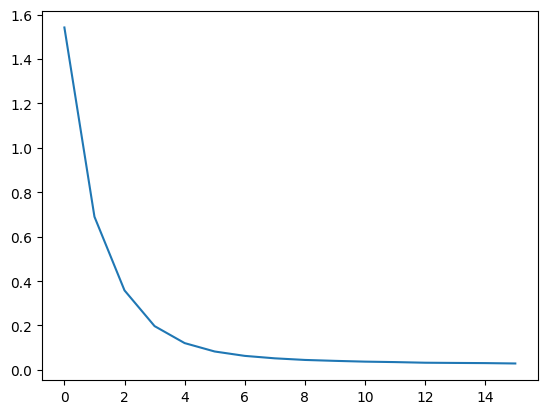

In [2]:
hidden_size = 128
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_lang, output_lang, pairs, train_dataloader = get_dataloader(batch_size, device)

encoder = EncoderRNN(input_lang.n_words, hidden_size).to(device)
decoder = AttnDecoderRNN(hidden_size, output_lang.n_words, device=device).to(device)

losses = train(train_dataloader, encoder, decoder, 80, print_every=5, plot_every=5)


def showPlot(points):
    plt.figure()
    fig, ax = plt.subplots()
    loc = ticker.MultipleLocator(base=0.2)
    ax.yaxis.set_major_locator(loc)
    plt.plot(points)


showPlot(losses)

In [3]:
encoder.eval()
decoder.eval()
evaluateRandomly(encoder, decoder, input_lang, output_lang, pairs, device)

> vous etes idiot
= you re being silly
< you are stupid stupid <EOS>

> je ne suis pas devin
= i m not a psychic
< i m not a psychic <EOS>

> il se plaint toujours de la nourriture
= he s always complaining about the food
< he s always complaining about the food <EOS>

> c est mon frere
= he is my brother
< he s my brother brother <EOS>

> ils sont inutiles
= they re useless
< i m useless <EOS>

> vous etes fiables
= you re reliable
< you re reliable <EOS>

> vous etes tres avisees
= you re very wise
< you re very wise <EOS>

> il va venir chez moi ce soir
= he is to come to my house tonight
< he is to come to my house tonight <EOS>

> je vous invite
= i m inviting you
< i m inviting you invited <EOS>

> elle est toujours libre l apres midi
= she is always free in the afternoon
< she is always free in the afternoon <EOS>



In [ ]:
def showAttention(input_sentence, output_words, attentions):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(attentions.cpu().numpy(), cmap="bone")
    fig.colorbar(cax)

    # Show label at every tick
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    # Set up axes
    ax.set_xticklabels([""] + input_sentence.split(" ") + ["<EOS>"], rotation=90)
    ax.set_yticklabels([""] + output_words)

    plt.show()


def evaluateAndShowAttention(input_sentence):
    output_words, attentions = evaluate(
        encoder, decoder, input_sentence, input_lang, output_lang, device
    )
    print("input =", input_sentence)
    print("output =", " ".join(output_words))
    showAttention(input_sentence, output_words, attentions[0, : len(output_words), :])


evaluateAndShowAttention("il n est pas aussi grand que son pere")
evaluateAndShowAttention("je suis trop fatigue pour conduire")
evaluateAndShowAttention("je suis desole si c est une question idiote")
evaluateAndShowAttention("je suis reellement fiere de vous")

TypeError: evaluate() missing 1 required positional argument: 'device'